<a href="https://colab.research.google.com/github/s00hyuk/metadata_consistency_analysis/blob/main/metadata_consistency_analysis(synthetic%2Bdata).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

─────────────────────────────────────────────────────────────────────────────
대규모 지방정부 데이터베이스 메타데이터 스키마 일관성 분석 파이프라인

논문: 대규모 지방정부 데이터베이스 메타데이터의 스키마 일관성 분석 방법론 및 충돌 탐지
데이터: 행정안전부 메타데이터등록관리시스템 (17개 시도, 2024년 말 기준)

실행 방법:
    python metadata_consistency_analysis.py --input metadata.csv --output results/

주요 출력:
    metadata_standardization_analysis.xlsx  ← 유사도·충돌 원본
    metadata_standardization_summary.xlsx   ← 요약 통계
    metadata_conflict_layer_summary.xlsx    ← 층위별 충돌 분석

의존 패키지:
    pandas, numpy, openpyxl
    pip install pandas numpy openpyxl
─────────────────────────────────────────────────────────────────────────────



In [ ]:

from __future__ import annotations

import argparse
import re
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd



In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

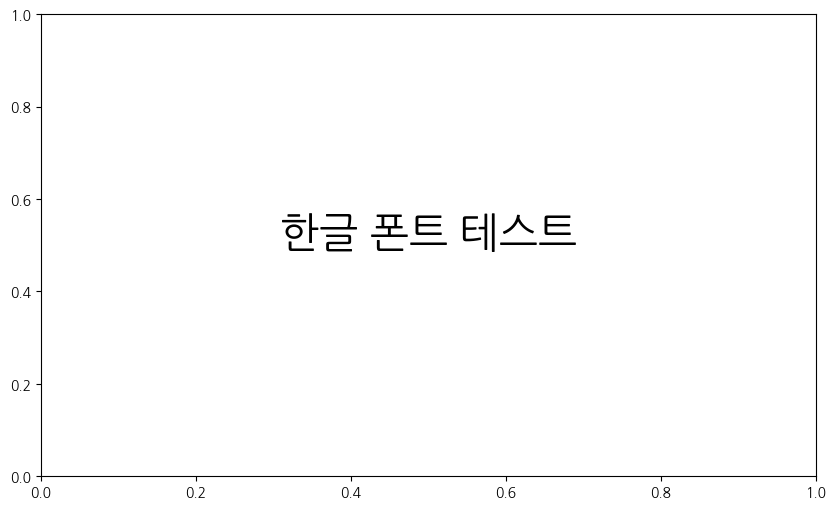

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl

# 나눔고딕 폰트를 matplotlib에 적용
mpl.rc('font', family='NanumGothic')

# 폰트가 잘 적용되었는지 확인하기 위해 한글 텍스트를 출력
plt.figure(figsize=(10, 6))
plt.text(0.5, 0.5, '한글 폰트 테스트', size=30, ha='center')
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 설정 (논문 3.3~3.6절 기준)
# ═══════════════════════════════════════════════════════════════════════════

# ── 플레이스홀더 명칭 ──────────────────────────────────────────────────────
# 실제 메타데이터가 아닌 수집 불가 항목의 일괄 표기 행 (인천광역시)
# 논문 3.3절: 제외테이블 15,628행, 비표준컬럼 23,037행
PLACEHOLDER_TABLES: set[str] = {"제외테이블"}
PLACEHOLDER_COLS:   set[str] = {"비표준컬럼"}

# ── 데이터타입 그룹화 매핑 ─────────────────────────────────────────────────
# 논문 3.3절: 세부 DBMS 타입 → 5개 그룹
DTYPE_PATTERNS: dict[str, list[str]] = {
    "문자형": ["CHAR", "VARCHAR", "TEXT", "CLOB", "STRING", "NCHAR", "NVARCHAR"],
    "숫자형": ["NUMBER", "INT", "INTEGER", "FLOAT", "DECIMAL", "NUMERIC", "DOUBLE"],
    "날짜형": ["DATE", "TIME", "TIMESTAMP"],
    "논리형": ["BOOLEAN", "BOOL"],
}

# ── Coverage ratio 기반 공통운영컬럼 Stoplist ──────────────────────────────
# 논문 3.6절 알고리즘 3: coverage ratio > θ AND 운영성 패턴 매칭
# 아래 집합은 전체 table-instance 상위 coverage 컬럼 중 운영성 패턴 매칭 결과
# 재현 시: detect_high_coverage_cols()로 후보 탐색 후 이 집합에 반영할 것
COMMON_ADMIN_COLS: set[str] = {
    "최종수정자ID", "최종수정일시", "등록자ID", "등록일", "비고", "청사구분",
    "최초등록자ID", "시군구코드", "민원접수번호", "최종수정일", "일련번호",
    "등록일자", "가명_1", "최초등록일시", "지역코드", "자치단체코드", "호",
    "도로명코드", "인허가등록번호", "특수지동", "년도", "특수주소", "특수지호",
    "사용여부", "도로명읍면동구분", "최종수정시점", "최초등록시점", "파일ID",
    "전화번호", "대표자명", "변경사유", "번지", "통", "반", "산", "건물본번",
    "건물부번", "삭제여부", "건물지하구분", "가명_2", "변경일자", "최종수정일자",
    "도로명시도시군구코드", "시도코드", "신고일자", "우편번호", "보건인허가번호",
    "대표자주민등록번호", "사업자등록번호", "보유시군구코드",
}

# ── 운영성 패턴 (coverage ratio 탐색 보조) ────────────────────────────────
ADMIN_PATTERN = re.compile(r"(등록|수정|삭제|사용|일시|일자|비고|순번|코드|변경|최초|최종)")

# ── 의미 범주 분류 패턴 (논문 3.8절) ─────────────────────────────────────
SEMANTIC_PATTERNS: list[tuple[str, re.Pattern]] = [
    ("식별자/코드",  re.compile(r"(번호|코드|ID|id|식별|키|KEY|key)")),
    ("시공간/주소",  re.compile(r"(주소|도로|지번|위치|좌표|경도|위도|시군구|읍면동|지역)")),
    ("시간/이력",    re.compile(r"(일시|일자|날짜|연도|년도|월|일$|시간|기간|이력|변경)")),
    ("분류/상태",    re.compile(r"(구분|유형|종류|상태|여부|분류|단계)")),
    ("명칭/인명",    re.compile(r"(명|이름|성명|대표자|담당자|작성자)")),
    ("내용/문서",    re.compile(r"(내용|설명|사유|비고|메모|첨부|문서|파일)")),
    ("수량/값",      re.compile(r"(수량|금액|비율|면적|건수|횟수|점수|값)")),
]


In [ ]:
import pandas as pd

# Github의 Raw 데이터 URL
url = "https://raw.githubusercontent.com/s00hyuk/metadata_consistency_analysis/main/synthetic_metadata.csv"

# 데이터 불러오기
df = pd.read_csv(url, encoding='utf-8')

# 데이터 확인
print(df.head())

/tmp/ipykernel_2042/3473398510.py:1: DtypeWarning: Columns (8,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/dataset/17개 시도 메타데이터_drop_cols.csv", encoding='utf-8')


In [ ]:
import pandas as pd
import numpy as np
import re
from itertools import combinations

# =========================================
# 0. 입력
# =========================================
# 예시:
# df = pd.read_csv("metadata.csv", encoding="utf-8-sig")
# 또는
# df = pd.read_excel("metadata.xlsx")

# df 변수에 데이터프레임 저장된 상황

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 1단계: 전처리 (알고리즘 1, O(n log n))
# ═══════════════════════════════════════════════════════════════════════════

def _clean_text(x) -> str | None:
    """결측·공백·'nan' 처리 + 다중 공백 정규화."""
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() == "nan":
        return None
    return re.sub(r"\s+", " ", s)


def _norm_korean(x) -> str | None:
    """한글 항목: 표면형 정규화만 적용 (동의어 통합 미수행)."""
    return _clean_text(x)


def _norm_english(x) -> str | None:
    """영문 항목: 대문자화 + 공백 제거 (언더스코어·하이픈·약어는 유지)."""
    s = _clean_text(x)
    return re.sub(r"\s+", "", s.upper()) if s else None


def _norm_table_open(x) -> str | None:
    """테이블 공개여부: 1→공개, 2→비공개."""
    if pd.isna(x):
        return None
    v = str(x).strip()
    return {"1": "공개", "2": "비공개"}.get(v)


def _norm_col_open(x) -> str | None:
    """컬럼 공개여부: Y→공개, N→비공개."""
    if pd.isna(x):
        return None
    v = str(x).strip().upper()
    return {"Y": "공개", "N": "비공개"}.get(v)


def _norm_pk(x) -> str | None:
    """PK 여부: Y/N 이외의 값은 None 처리 (논문 3.3절 수정 v2).
    기존 코드에서 Y/N 이외 값이 충돌 집계에 포함되던 버그를 수정.
    """
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    return s if s in {"Y", "N"} else None


def _dtype_group(x) -> str | None:
    """데이터타입 → 5개 그룹 (문자형·숫자형·날짜형·논리형·기타)."""
    s = _clean_text(x)
    if not s:
        return None
    upper = s.upper()
    for group, keywords in DTYPE_PATTERNS.items():
        if any(k in upper for k in keywords):
            return group
    return "기타"


def normalize(df: pd.DataFrame) -> pd.DataFrame:
    """원시 데이터프레임을 분석 가능한 형태로 정규화한다.

    컬럼명 요건:
        기관명, 정보시스템명, 한글 테이블명, 영문 테이블명,
        한글 컬럼명, 영문 컬럼명, 데이터타입,
        공개/비공개(테이블), 공개/비공개여부(컬럼),
        비공개사유(테이블), 비공개사유(컬럼), PK정보
    """
    w = df.copy()

    w["기관명_n"]       = w["기관명"].map(_norm_korean)
    w["정보시스템명_n"]  = w["정보시스템명"].map(_norm_korean)
    w["한글 테이블명_n"] = w["한글 테이블명"].map(_norm_korean)
    w["영문 테이블명_n"] = w["영문 테이블명"].map(_norm_english)
    w["한글 컬럼명_n"]  = w["한글 컬럼명"].map(_norm_korean)
    w["영문 컬럼명_n"]  = w["영문 컬럼명"].map(_norm_english)

    w["table_open_n"]   = w["공개/비공개(테이블)"].map(_norm_table_open)
    w["column_open_n"]  = w["공개/비공개여부(컬럼)"].map(_norm_col_open)
    w["PK정보_n"]       = w["PK정보"].map(_norm_pk)
    w["datatype_group"] = w["데이터타입"].map(_dtype_group)

    # 테이블 인스턴스 식별자 (기관·시스템·한글테이블·영문테이블)
    w["table_instance_id"] = (
        w["기관명_n"].fillna("")      + "||" +
        w["정보시스템명_n"].fillna("") + "||" +
        w["한글 테이블명_n"].fillna("") + "||" +
        w["영문 테이블명_n"].fillna("")
    )

    return w


def build_column_table(w: pd.DataFrame) -> pd.DataFrame:
    """전처리된 데이터프레임에서 분석용 컬럼 테이블을 생성한다.

    적용 순서:
        1. 필수 키 결측 행 제거
        2. 플레이스홀더 행 제거 (논문 3.3절)
        3. 기관 내 중복 제거 (키 기준 첫 행 유지, O(n log n))
    """
    KEEP_COLS = [
        "기관명_n", "정보시스템명_n", "한글 테이블명_n", "영문 테이블명_n",
        "한글 컬럼명_n", "영문 컬럼명_n",
        "table_open_n", "column_open_n",
        "datatype_group", "PK정보_n",
        "table_instance_id",
    ]
    KEY_COLS = ["기관명_n", "정보시스템명_n", "한글 테이블명_n", "한글 컬럼명_n"]

    t = w[KEEP_COLS].dropna(subset=KEY_COLS).copy()

    # 1) 플레이스홀더 제거
    n_before = len(t)
    t = t[~t["한글 테이블명_n"].isin(PLACEHOLDER_TABLES)]
    t = t[~t["한글 컬럼명_n"].isin(PLACEHOLDER_COLS)]
    n_after = len(t)
    print(f"[전처리] 플레이스홀더 제거: -{n_before - n_after:,}행 → 잔여 {n_after:,}행")

    # 2) 기관 내 중복 제거 (첫 행 유지)
    #    영향 범위: 중복 행 중 공개여부 불일치 사례 7,741건(1.92%)으로 제한적
    n_before2 = len(t)
    t = t.drop_duplicates(subset=KEY_COLS, keep="first")
    n_after2 = len(t)
    print(f"[전처리] 기관 내 중복 제거: -{n_before2 - n_after2:,}행 → 잔여 {n_after2:,}행")

    return t.reset_index(drop=True)



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 2단계: 비교가능 테이블 그룹(CTG) 구성
# ═══════════════════════════════════════════════════════════════════════════

def build_ctg(col_tbl: pd.DataFrame) -> pd.DataFrame:
    """동일 정보시스템명 × 동일 한글 테이블명을 기준으로 CTG를 구성한다.

    조건: 2개 이상의 기관이 포함된 그룹만 반환.
    """
    groups = (
        col_tbl[["기관명_n", "정보시스템명_n", "한글 테이블명_n", "영문 테이블명_n"]]
        .drop_duplicates()
        .groupby(["정보시스템명_n", "한글 테이블명_n"], dropna=False)
        .agg(
            기관수=("기관명_n", "nunique"),
            기관목록=("기관명_n", lambda s: ", ".join(sorted(s.dropna().unique()))),
            영문테이블명수=("영문 테이블명_n", lambda s: s.dropna().nunique()),
            영문테이블명목록=("영문 테이블명_n", lambda s: ", ".join(sorted(s.dropna().unique()))),
        )
        .reset_index()
    )
    ctg = groups[groups["기관수"] >= 2].copy()
    ctg.sort_values(["기관수", "정보시스템명_n", "한글 테이블명_n"],
                    ascending=[False, True, True], inplace=True)
    print(f"[CTG 구성] 총 {len(ctg):,}개 비교가능 테이블 그룹 (기관 ≥ 2)")
    return ctg.reset_index(drop=True)



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 3단계: 구조 표준성 측정 — Jaccard 계수 (알고리즘 2)
# ═══════════════════════════════════════════════════════════════════════════

def _jaccard(a: set, b: set) -> float:
    """두 집합의 Jaccard 유사도. 둘 다 공집합이면 1.0 반환."""
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def compute_similarity(
    col_tbl: pd.DataFrame,
    ctg: pd.DataFrame,
    exclude_admin: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """CTG별 구조 표준성 지표와 쌍별 Jaccard를 계산한다.

    Args:
        col_tbl:       build_column_table() 결과
        ctg:           build_ctg() 결과
        exclude_admin: True → COMMON_ADMIN_COLS 제외(filtered), False → raw

    Returns:
        (summary_df, pairwise_df)
    """
    GROUP_KEYS = ["정보시스템명_n", "한글 테이블명_n"]

    data = col_tbl.merge(ctg[GROUP_KEYS], on=GROUP_KEYS, how="inner")
    if exclude_admin:
        data = data[~data["한글 컬럼명_n"].isin(COMMON_ADMIN_COLS)].copy()

    summaries = []
    pairs = []

    for (sys_nm, tbl_nm), grp in data.groupby(GROUP_KEYS, dropna=False):
        # 기관별 컬럼 집합
        inst: dict[str, set] = {
            org: set(sub["한글 컬럼명_n"].dropna().unique())
            for org, sub in grp.groupby("기관명_n")
        }
        orgs = sorted(inst)
        sets = [inst[o] for o in orgs]

        if not sets:
            continue

        union_cols = set.union(*sets)
        inter_cols = set.intersection(*sets)

        # 쌍별 Jaccard
        pair_jacs = []
        for org_a, org_b in combinations(orgs, 2):
            sa, sb = inst[org_a], inst[org_b]
            jac = _jaccard(sa, sb)
            pair_jacs.append(jac)
            pairs.append({
                "정보시스템명":   sys_nm,
                "한글 테이블명":  tbl_nm,
                "기관A":          org_a,
                "기관B":          org_b,
                "A_컬럼수":       len(sa),
                "B_컬럼수":       len(sb),
                "공통컬럼수":     len(sa & sb),
                "A_only":         len(sa - sb),
                "B_only":         len(sb - sa),
                "Jaccard":        round(jac, 4),
                "A_only_예시":    ", ".join(sorted(sa - sb)[:20]),
                "B_only_예시":    ", ".join(sorted(sb - sa)[:20]),
                "공통운영컬럼제외": exclude_admin,
            })

        summaries.append({
            "정보시스템명":     sys_nm,
            "한글 테이블명":    tbl_nm,
            "기관수":           len(orgs),
            "기관목록":         ", ".join(orgs),
            "컬럼합집합수":     len(union_cols),
            "전기관공통컬럼수": len(inter_cols),
            "전기관공통비율":   round(len(inter_cols) / len(union_cols), 4) if union_cols else np.nan,
            "평균쌍별Jaccard":  round(float(np.mean(pair_jacs)), 4) if pair_jacs else 1.0,
            "최소쌍별Jaccard":  round(float(np.min(pair_jacs)), 4) if pair_jacs else 1.0,
            "완전동일컬럼집합여부": len({frozenset(v) for v in inst.values()}) == 1,
            "영문테이블명수":   grp["영문 테이블명_n"].dropna().nunique(),
            "공통운영컬럼제외": exclude_admin,
        })

    summary_df = (
        pd.DataFrame(summaries)
        .sort_values(["평균쌍별Jaccard", "기관수"], ascending=[True, False])
        .reset_index(drop=True)
    )
    pairwise_df = (
        pd.DataFrame(pairs)
        .sort_values(["Jaccard", "정보시스템명", "한글 테이블명"], ascending=[True, True, True])
        .reset_index(drop=True)
    )
    return summary_df, pairwise_df



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4단계: 컬럼 메타데이터 충돌 탐지
# ═══════════════════════════════════════════════════════════════════════════

def detect_conflicts(
    col_tbl: pd.DataFrame,
    ctg: pd.DataFrame,
    exclude_admin: bool = True,
) -> pd.DataFrame:
    """CTG 내에서 동일 한글 컬럼명을 공유하는 기관 간 메타데이터 충돌을 탐지한다.

    충돌 판정 기준 (논문 표 1):
        - 영문 컬럼명 상이 값 ≥ 2  → 구조 충돌
        - 데이터타입 그룹 종류 ≥ 2  → 구조 충돌
        - PK Y/N 혼재               → 구조 충돌
        - 공개여부 공개/비공개 혼재  → 거버넌스 충돌

    기관 내 중복 통제(build_column_table) 이후이므로 탐지된 충돌은
    순수하게 기관 간 편차만을 반영한다.
    """
    GROUP_KEYS = ["정보시스템명_n", "한글 테이블명_n"]

    data = col_tbl.merge(ctg[GROUP_KEYS], on=GROUP_KEYS, how="inner").copy()
    if exclude_admin:
        data = data[~data["한글 컬럼명_n"].isin(COMMON_ADMIN_COLS)]

    rows = []
    for (sys_nm, tbl_nm, col_kr), grp in data.groupby(
        GROUP_KEYS + ["한글 컬럼명_n"], dropna=False
    ):
        if grp["기관명_n"].nunique() < 2:
            continue

        en_vals   = sorted(grp["영문 컬럼명_n"].dropna().unique())
        dtype_vals = sorted(grp["datatype_group"].dropna().unique())
        open_vals  = sorted(grp["column_open_n"].dropna().unique())
        pk_vals    = sorted(grp["PK정보_n"].dropna().unique())

        # 하나라도 다르면 충돌
        if not (len(en_vals) > 1 or len(dtype_vals) > 1
                or len(open_vals) > 1 or len(pk_vals) > 1):
            continue

        rows.append({
            "정보시스템명":       sys_nm,
            "한글 테이블명":      tbl_nm,
            "한글 컬럼명":        col_kr,
            "기관수":             grp["기관명_n"].nunique(),
            "기관목록":           ", ".join(sorted(grp["기관명_n"].dropna().unique())),
            "영문컬럼명수":       len(en_vals),
            "영문컬럼명목록":     ", ".join(en_vals),
            "데이터타입그룹수":   len(dtype_vals),
            "데이터타입그룹목록": ", ".join(dtype_vals),
            "공개여부종류수":     len(open_vals),
            "공개여부목록":       ", ".join(open_vals),
            "PK종류수":           len(pk_vals),
            "PK목록":             ", ".join(pk_vals),
        })

    conflict_df = (
        pd.DataFrame(rows)
        .sort_values(["기관수", "정보시스템명", "한글 테이블명", "한글 컬럼명"],
                     ascending=[False, True, True, True])
        .reset_index(drop=True)
    )
    print(f"[충돌 탐지] 총 {len(conflict_df):,}건 "
          f"({'admin 제외' if exclude_admin else 'raw'})")
    return conflict_df



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5단계: Coverage ratio 기반 Stoplist 후보 탐색 (알고리즘 3)
# ═══════════════════════════════════════════════════════════════════════════

def detect_high_coverage_cols(
    col_tbl: pd.DataFrame,
    top_n: int = 100,
) -> pd.DataFrame:
    """Coverage ratio가 높은 컬럼 후보를 탐색한다.

    coverage(c) = cnt(c) / N
    여기서 cnt(c)는 컬럼 c가 등장하는 고유 table-instance 수,
    N은 전체 고유 table-instance 수.

    결과를 ADMIN_PATTERN으로 필터링하면 stoplist 후보를 좁힐 수 있다.
    """
    total_instances = col_tbl["table_instance_id"].nunique()

    freq = (
        col_tbl[["table_instance_id", "한글 컬럼명_n"]]
        .drop_duplicates()
        .groupby("한글 컬럼명_n")["table_instance_id"]
        .nunique()
        .reset_index(name="instance_count")
    )
    freq["coverage_ratio"] = freq["instance_count"] / total_instances
    freq["admin_pattern"]  = freq["한글 컬럼명_n"].map(
        lambda x: bool(ADMIN_PATTERN.search(x)) if isinstance(x, str) else False
    )
    freq.sort_values("coverage_ratio", ascending=False, inplace=True)

    return freq.head(top_n).reset_index(drop=True)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6단계: Raw / Filtered 민감도 분석
# ═══════════════════════════════════════════════════════════════════════════

def sensitivity_analysis(
    sim_raw: pd.DataFrame,
    sim_filtered: pd.DataFrame,
) -> dict:
    """Raw와 Filtered 결과를 비교하여 민감도 지표를 반환한다."""
    GROUP_KEYS = ["정보시스템명", "한글 테이블명"]

    merged = sim_raw.merge(
        sim_filtered,
        on=GROUP_KEYS,
        suffixes=("_raw", "_filt"),
        how="inner",
    )

    delta = (merged["평균쌍별Jaccard_raw"] - merged["평균쌍별Jaccard_filt"]).abs()

    return {
        "group_count_raw":      len(sim_raw),
        "group_count_filtered": len(sim_filtered),
        "same_value_ratio":     round((delta == 0).mean(), 4),
        "mean_abs_delta":       round(delta.mean(), 6),
        "gt_001_ratio":         round((delta > 0.01).mean(), 4),
    }



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 부록: 편차 컬럼 의미 범주 분류 (논문 3.8절)
# ═══════════════════════════════════════════════════════════════════════════

def classify_semantic_category(name: str) -> str:
    """한글 컬럼명을 8개 의미 범주로 분류한다 (탐색적 보조분석).

    주의: 정규표현식 기반 분류로 완전한 의미론적 분류가 아님.
    """
    if not isinstance(name, str):
        return "기타"
    for category, pattern in SEMANTIC_PATTERNS:
        if pattern.search(name):
            return category
    return "기타"


def analyze_conflict_semantics(conflict_df: pd.DataFrame) -> pd.DataFrame:
    """충돌 컬럼의 의미 범주별 분포와 충돌 유형 비율을 집계한다."""
    conf = conflict_df.copy()

    # 충돌 플래그
    conf["영문컬럼명충돌"]   = conf["영문컬럼명수"]       > 1
    conf["데이터타입충돌"]   = conf["데이터타입그룹수"]   > 1
    conf["공개여부충돌"]     = conf["공개여부종류수"]     > 1
    conf["PK충돌"]           = conf["PK종류수"]           > 1
    conf["구조충돌"]         = conf[["영문컬럼명충돌", "데이터타입충돌", "PK충돌"]].any(axis=1)
    conf["거버넌스충돌"]     = conf["공개여부충돌"]
    conf["의미범주"]         = conf["한글 컬럼명"].map(classify_semantic_category)

    result = (
        conf.groupby("의미범주")
        .agg(
            충돌수=("한글 컬럼명", "count"),
            거버넌스충돌수=("거버넌스충돌", "sum"),
            구조충돌수=("구조충돌", "sum"),
        )
        .reset_index()
    )
    total = result["충돌수"].sum()
    result["비중(%)"]             = (result["충돌수"] / total * 100).round(2)
    result["거버넌스충돌비율(%)"] = (result["거버넌스충돌수"] / result["충돌수"] * 100).round(2)
    result["구조충돌비율(%)"]     = (result["구조충돌수"]     / result["충돌수"] * 100).round(2)

    return result.sort_values("충돌수", ascending=False).reset_index(drop=True)



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 결과 요약 출력
# ═══════════════════════════════════════════════════════════════════════════

def _print_section(title: str) -> None:
    print(f"\n{'═' * 60}")
    print(f"  {title}")
    print('═' * 60)


def print_summary(
    sim_filtered: pd.DataFrame,
    conflict_df: pd.DataFrame,
    sens: dict,
) -> None:
    """논문 표 2~7에 대응하는 주요 지표를 콘솔에 출력한다."""
    _print_section("구조 표준성 요약 (filtered)")
    n = len(sim_filtered)
    print(f"  비교가능 테이블 그룹 수       : {n:,}")
    print(f"  평균 쌍별 Jaccard 평균        : {sim_filtered['평균쌍별Jaccard'].mean():.4f}")
    print(f"  평균 쌍별 Jaccard 중앙값      : {sim_filtered['평균쌍별Jaccard'].median():.4f}")
    print(f"  완전 동일 컬럼집합 비율       : {sim_filtered['완전동일컬럼집합여부'].mean():.4%}")
    print(f"  평균 Jaccard < 0.95 그룹 수   : {(sim_filtered['평균쌍별Jaccard'] < 0.95).sum():,}")
    print(f"  평균 Jaccard < 0.50 그룹 수   : {(sim_filtered['평균쌍별Jaccard'] < 0.50).sum():,}")

    _print_section("민감도 분석 (raw vs filtered)")
    print(f"  동일 결과 그룹 비율           : {sens['same_value_ratio']:.4%}")
    print(f"  평균 절대 변화 (Jaccard)       : {sens['mean_abs_delta']:.6f}")
    print(f"  0.01 초과 변화 그룹 비율      : {sens['gt_001_ratio']:.4%}")

    _print_section("충돌 층위 요약 (filtered, N=충돌건수)")
    conf = conflict_df.copy()
    conf["구조충돌"]   = ((conf["영문컬럼명수"] > 1) |
                         (conf["데이터타입그룹수"] > 1) |
                         (conf["PK종류수"] > 1))
    conf["거버넌스충돌"] = conf["공개여부종류수"] > 1
    total = len(conf)
    print(f"  전체 충돌                      : {total:,}건")
    print(f"  ├ 거버넌스 충돌 (분모=충돌건수) : {conf['거버넌스충돌'].sum():,}건 "
          f"({conf['거버넌스충돌'].mean():.2%})")
    print(f"  └ 구조 충돌   (분모=충돌건수)   : {conf['구조충돌'].sum():,}건 "
          f"({conf['구조충돌'].mean():.2%})")
    print(f"  ※ 전체 비교대상 컬럼-기관쌍 대비 충돌 발생 비율은 별도 집계 필요")



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 저장
# ═══════════════════════════════════════════════════════════════════════════

def save_results(
    out_dir: Path,
    ctg: pd.DataFrame,
    sim_raw: pd.DataFrame,
    sim_filtered: pd.DataFrame,
    pairwise_raw: pd.DataFrame,
    pairwise_filtered: pd.DataFrame,
    conflict_raw: pd.DataFrame,
    conflict_filtered: pd.DataFrame,
    freq_admin: pd.DataFrame,
    semantic_df: pd.DataFrame,
) -> None:
    """분석 결과를 세 개의 Excel 파일로 저장한다."""
    out_dir.mkdir(parents=True, exist_ok=True)

    # ① 유사도·충돌 원본
    path1 = out_dir / "metadata_standardization_analysis.xlsx"
    with pd.ExcelWriter(path1, engine="openpyxl") as w:
        ctg.to_excel(w, sheet_name="same_table_groups",      index=False)
        sim_raw.to_excel(w, sheet_name="table_similarity_raw",      index=False)
        sim_filtered.to_excel(w, sheet_name="table_similarity_filtered", index=False)
        pairwise_raw.to_excel(w, sheet_name="pairwise_raw",          index=False)
        pairwise_filtered.to_excel(w, sheet_name="pairwise_filtered",index=False)
        conflict_raw.to_excel(w, sheet_name="column_meta_conflicts_raw",      index=False)
        conflict_filtered.to_excel(w, sheet_name="column_meta_conflicts",     index=False)
        freq_admin.to_excel(w, sheet_name="frequent_admin_candidates", index=False)
    print(f"[저장] {path1}")

    # ② 충돌 층위 분석
    path2 = out_dir / "metadata_conflict_layer_summary.xlsx"
    conf = conflict_filtered.copy()
    conf["구조충돌"]     = ((conf["영문컬럼명수"] > 1) |
                            (conf["데이터타입그룹수"] > 1) |
                            (conf["PK종류수"] > 1))
    conf["거버넌스충돌"] = conf["공개여부종류수"] > 1

    layer_summary = pd.DataFrame({
        "구분":   ["전체충돌", "구조충돌", "거버넌스충돌",
                   "구조만충돌", "거버넌스만충돌", "둘다충돌"],
        "건수":   [
            len(conf),
            int(conf["구조충돌"].sum()),
            int(conf["거버넌스충돌"].sum()),
            int((conf["구조충돌"] & ~conf["거버넌스충돌"]).sum()),
            int((~conf["구조충돌"] & conf["거버넌스충돌"]).sum()),
            int((conf["구조충돌"] & conf["거버넌스충돌"]).sum()),
        ],
    })
    layer_summary["비율(%)"] = (layer_summary["건수"] / len(conf) * 100).round(2)

    system_summary = (
        conf.groupby("정보시스템명")
        .agg(
            충돌건수=("한글 컬럼명", "count"),
            구조충돌=("구조충돌", "sum"),
            거버넌스충돌=("거버넌스충돌", "sum"),
            영문명충돌=("영문컬럼명수", lambda s: (s > 1).sum()),
            타입충돌=("데이터타입그룹수", lambda s: (s > 1).sum()),
            PK충돌=("PK종류수", lambda s: (s > 1).sum()),
            공개여부충돌=("공개여부종류수", lambda s: (s > 1).sum()),
        )
        .reset_index()
        .sort_values("충돌건수", ascending=False)
    )

    gov_only = conf[(~conf["구조충돌"]) & conf["거버넌스충돌"]].copy()
    struct_only = conf[conf["구조충돌"]].copy()

    with pd.ExcelWriter(path2, engine="openpyxl") as w:
        layer_summary.to_excel(w, sheet_name="layer_summary",   index=False)
        system_summary.to_excel(w, sheet_name="system_summary", index=False)
        semantic_df.to_excel(w, sheet_name="semantic_category", index=False)
        gov_only.to_excel(w, sheet_name="gov_only_cases",       index=False)
        struct_only.to_excel(w, sheet_name="struct_cases",      index=False)
    print(f"[저장] {path2}")


In [ ]:
import argparse
import pandas as pd
from pathlib import Path

# ═══════════════════════════════════════════════════════════════════════════
# 메인
# ═══════════════════════════════════════════════════════════════════════════

def load_data(path: str) -> pd.DataFrame:
    """CSV 또는 Excel 파일을 읽는다."""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"데이터 파일을 찾을 수 없음: {path}")
    if p.suffix.lower() == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
            try:
                return pd.read_csv(path, encoding=enc, low_memory=False)
            except UnicodeDecodeError:
                continue
        raise ValueError("CSV 인코딩 자동 감지 실패. 인코딩을 직접 지정하세요.")
    return pd.read_excel(path)


def main(input_path: str, output_dir: str = "results") -> None:
    """전체 분석 파이프라인을 순차 실행한다."""

    out = Path(output_dir)

    # ── 1. 데이터 로드 ────────────────────────────────────────────────────
    print(f"\n[1/6] 데이터 로드: {input_path}")
    df = load_data(input_path)
    print(f"      원시 레코드: {len(df):,}행, {df.shape[1]}개 컬럼")

    # ── 2. 전처리 ─────────────────────────────────────────────────────────
    print("\n[2/6] 전처리")
    w = normalize(df)
    col_tbl = build_column_table(w)

    # ── 3. CTG 구성 ───────────────────────────────────────────────────────
    print("\n[3/6] CTG 구성")
    ctg = build_ctg(col_tbl)

    # ── 4. 구조 표준성 측정 ───────────────────────────────────────────────
    print("\n[4/6] 구조 표준성 측정 (raw / filtered)")
    sim_raw, pairwise_raw = compute_similarity(col_tbl, ctg, exclude_admin=False)
    sim_filt, pairwise_filt = compute_similarity(col_tbl, ctg, exclude_admin=True)

    # ── 5. 충돌 탐지 ──────────────────────────────────────────────────────
    print("\n[5/6] 메타데이터 충돌 탐지")
    conflict_raw  = detect_conflicts(col_tbl, ctg, exclude_admin=False)
    conflict_filt = detect_conflicts(col_tbl, ctg, exclude_admin=True)

    # ── 5b. 보조 분석 ─────────────────────────────────────────────────────
    freq_admin   = detect_high_coverage_cols(col_tbl, top_n=100)
    semantic_df  = analyze_conflict_semantics(conflict_filt)
    sens         = sensitivity_analysis(sim_raw, sim_filt)

    # ── 6. 결과 출력 및 저장 ─────────────────────────────────────────────
    print("\n[6/6] 결과 저장")
    print_summary(sim_filt, conflict_filt, sens)
    save_results(
        out, ctg,
        sim_raw, sim_filt,
        pairwise_raw, pairwise_filt,
        conflict_raw, conflict_filt,
        freq_admin, semantic_df,
    )
    print(f"\n완료. 결과 디렉터리: {out.resolve()}")


if __name__ == "__main__":
    # 1. 합성 데이터 URL 정의
    synthetic_url = "https://raw.githubusercontent.com/s00hyuk/metadata_consistency_analysis/main/synthetic_metadata.csv"

    # 2. 결과 저장 디렉토리 설정
    output_directory = "results"

    # 3. 데이터 로드 로직 수정 (URL 직접 지원)
    def load_data_v2(path: str) -> pd.DataFrame:
        if path.startswith("http"):
            return pd.read_csv(path, low_memory=False)
        # 기존 로컬 파일 로드 로직 유지
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(f"파일 없음: {path}")
        return pd.read_csv(path, encoding='utf-8', low_memory=False)

    # 4. main 함수 실행 (기존 main 내의 load_data를 대체하거나 아래처럼 직접 수행)
    # 여기서는 기존 main 함수 구조를 존중하여 경로만 넘깁니다.
    # 단, main 함수 내부에서 load_data(input_path)를 호출하므로
    # 위에서 정의한 load_data 함수가 URL을 처리할 수 있어야 합니다.

    try:
        # Colab 환경에서 URL로 직접 실행되도록 호출
        main(synthetic_url, output_directory)
    except Exception as e:
        print(f"실행 중 오류 발생: {e}")



[1/6] 데이터 로드: /content/drive/MyDrive/dataset/17개 시도 메타데이터_drop_cols.csv
      원시 레코드: 3,703,676행, 16개 컬럼

[2/6] 전처리
[전처리] 플레이스홀더 제거: -23,037행 → 잔여 3,680,639행
[전처리] 기관 내 중복 제거: -402,281행 → 잔여 3,278,358행

[3/6] CTG 구성
[CTG 구성] 총 6,468개 비교가능 테이블 그룹 (기관 ≥ 2)

[4/6] 구조 표준성 측정 (raw / filtered)

[5/6] 메타데이터 충돌 탐지
[충돌 탐지] 총 1,881건 (raw)
[충돌 탐지] 총 1,595건 (admin 제외)

[6/6] 결과 저장

════════════════════════════════════════════════════════════
  구조 표준성 요약 (filtered)
════════════════════════════════════════════════════════════
  비교가능 테이블 그룹 수       : 6,466
  평균 쌍별 Jaccard 평균        : 0.9920
  평균 쌍별 Jaccard 중앙값      : 1.0000
  완전 동일 컬럼집합 비율       : 95.0201%
  평균 Jaccard < 0.95 그룹 수   : 208
  평균 Jaccard < 0.50 그룹 수   : 26

════════════════════════════════════════════════════════════
  민감도 분석 (raw vs filtered)
════════════════════════════════════════════════════════════
  동일 결과 그룹 비율           : 96.4000%
  평균 절대 변화 (Jaccard)       : 0.000442
  0.01 초과 변화 그룹 비율      : 1.0500%

══════════════════